# 06 — Multi-seed descriptor benchmark

Compare four matched-encoder descriptor models on all five splits with three seeds.
This notebook is the stable baseline that later diagnostic and novelty experiments
(Van't Hoff diagnostics, joint distribution shift, temperature sparsity, GNN) will
build on. It replaces the notebook-only Stage 2 result with a multi-seed table.


## 1. Goal

Establish a stable descriptor-model benchmark before any new experiments. The
scientific comparison is between two ways of getting a temperature-dependent
solubility prediction out of the same RDKit descriptors:

**Direct**
$$\text{logS}(T) = f_\theta(\mathbf{x}_\text{sol}, \mathbf{x}_\text{solv}, T)$$

**Thermodynamic (Van't Hoff)**
$$(\hat a, \hat\beta) = f_\theta(\mathbf{x}_\text{sol}, \mathbf{x}_\text{solv})$$
$$\text{logS}(T) = \hat a + \hat\beta \cdot b_\text{scale} \cdot \left(\frac{1}{T_\text{ref}} - \frac{1}{T}\right)$$

Both share the same descriptors, backbone, optimizer, batch size, epoch budget,
and split indices. Only the way temperature enters differs.

Four models are compared:

| Model | Temperature input | Head | log S(T) |
|---|---|---|---|
| A direct | raw $T$ appended to features | linear → 1 | predicted directly |
| D 1/T control | $[T, 1/T]$ appended to features | linear → 1 | predicted directly |
| B Van't Hoff (stock) | none | linear → $(a, b)$ | $a + b\cdot z$ |
| Bc Van't Hoff (conditioned) | none | linear → $(a, \beta)$ | $a + \beta \cdot b_\text{scale} \cdot z$ |

where $z \equiv 1/T_\text{ref} - 1/T$ and $T_\text{ref} = 298.15\,\text{K}$.

Bc is a reparameterization of B with `b_scale` fixed to a training-only estimate
of typical Van't Hoff slope magnitude. Same function class; the intended purpose
is to make the head outputs $(a, \beta)$ live on comparable numerical scales so
the slope gradient is not attenuated by $|z| \sim 10^{-3}$.

Model D is the control that isolates the "1/T as a feature" effect from
"impose the Van't Hoff functional form" — both are ways to expose 1/T to the
network, but only B/Bc constrain how log S varies with T.


## 2. Load prepared data and frozen splits

Everything below reads from files produced by notebooks 01–03. Do not rebuild
descriptors or splits here; the point of a benchmark is that the inputs are frozen.


In [1]:
import json
import sys
import time
from pathlib import Path

import numpy as np
import pandas as pd
import torch

ROOT = Path.cwd().parent
sys.path.insert(0, str(ROOT / "scripts"))

from train import (  # noqa: E402
    RES, HIDDEN, DROPOUT, LR, WEIGHT_DECAY, BATCH_SIZE,
    MAX_EPOCHS, PATIENCE, EARLY_STOP_MIN_DELTA, GRAD_CLIP,
    SPLIT_NAMES, load_features, load_split, train_one,
    metrics_row, save_preds,
)
from models import T_REF  # noqa: E402

print(f"repo root:     {ROOT}")
print(f"results dir:   {RES}")
print(f"pytorch:       {torch.__version__}")
print(f"cpu threads:   {torch.get_num_threads()}")


repo root:     /home/sg182/ML_Projects/BigSolDB-T
results dir:   /home/sg182/ML_Projects/BigSolDB-T/results
pytorch:       2.13.0+cu130
cpu threads:   4


In [2]:
X_desc, T_arr, y, pair_id = load_features()
print(f"measurements:            {len(y):,}")
print(f"descriptor dim (solute+solvent): {X_desc.shape[1]}  "
      f"({X_desc.shape[1] - 149} solute + 149 solvent)")
print(f"unique pair ids:         {len(np.unique(pair_id)):,}")
print(f"T range (K):             {T_arr.min():.2f} – {T_arr.max():.2f}")
print(f"logS range:              {y.min():.2f} – {y.max():.2f}")

split_sizes = {}
for s in SPLIT_NAMES:
    tr, va, te = load_split(s)
    split_sizes[s] = (len(tr), len(va), len(te))
pd.DataFrame(split_sizes, index=["train", "val", "test"]).T


measurements:            100,983
descriptor dim (solute+solvent): 347  (198 solute + 149 solvent)
unique pair ids:         10,855
T range (K):             243.15 – 425.77
logS range:              -9.13 – 2.49


,train,val,test
random,80786,10098,10099
textrap,67902,7385,25696
coldsol,81610,8937,10436
coldpair,80806,10187,9990
coldsolv,77981,11262,11740


In [3]:
B_SCALE_JSON = RES / "b_scale.json"
with open(B_SCALE_JSON) as fh:
    b_scale_meta = json.load(fh)

b_scales = {s: b_scale_meta["splits"][s]["b_scale"] for s in SPLIT_NAMES}
b_scale_rows = []
for s in SPLIT_NAMES:
    info = b_scale_meta["splits"][s]
    b_scale_rows.append({
        "split": s,
        "b_scale (K)": info["b_scale"],
        "n_pairs_used": info["n_pairs_used"],
        "n_pairs_in_train": info["n_pairs_in_train"],
    })
print(f"b_scale eligibility:  >= {b_scale_meta['meta']['eligibility']['min_rows_per_pair']} rows AND "
      f">= {b_scale_meta['meta']['eligibility']['min_distinct_temperatures']} distinct temperatures per pair")
pd.DataFrame(b_scale_rows).set_index("split")


b_scale eligibility:  >= 2 rows AND >= 2 distinct temperatures per pair


,b_scale (K),n_pairs_used,n_pairs_in_train
split,,,
random,1381.781494,10496,10791
textrap,1342.211365,10502,10854
coldsol,1387.116516,8490,8736
coldpair,1381.238770,8416,8684
coldsolv,1386.245728,8140,8434


## 3. Experimental configuration

Everything the sweep touches is either loaded from a frozen file (features, splits,
b_scale) or fixed by the constants below. The training hyperparameters are the
originals from `notebooks/04_train.ipynb`, imported through `scripts/train.py`
so this notebook cannot silently drift.


In [4]:
SEEDS = [42, 123, 456]
MODELS = ["A", "D", "B", "Bc"]
SPLITS = list(SPLIT_NAMES)  # ["random", "textrap", "coldsol", "coldpair", "coldsolv"]
DEVICE = "cpu"

print(f"seeds:   {SEEDS}")
print(f"models:  {MODELS}")
print(f"splits:  {SPLITS}")
print(f"total runs: {len(MODELS) * len(SPLITS) * len(SEEDS)} = "
      f"{len(MODELS)} models x {len(SPLITS)} splits x {len(SEEDS)} seeds")

# Frozen training config imported from scripts/train.py (do not override here).
print()
print("frozen training configuration (from scripts/train.py):")
print(f"  hidden dims       : {HIDDEN}")
print(f"  dropout           : {DROPOUT}")
print(f"  optimizer         : AdamW")
print(f"  learning rate     : {LR}")
print(f"  weight decay      : {WEIGHT_DECAY}")
print(f"  batch size        : {BATCH_SIZE}")
print(f"  max epochs        : {MAX_EPOCHS}")
print(f"  early stop patience: {PATIENCE}  (min-delta {EARLY_STOP_MIN_DELTA})")
print(f"  grad clip (norm)  : {GRAD_CLIP}")
print(f"  T_ref             : {T_REF} K")


seeds:   [42, 123, 456]
models:  ['A', 'D', 'B', 'Bc']
splits:  ['random', 'textrap', 'coldsol', 'coldpair', 'coldsolv']
total runs: 60 = 4 models x 5 splits x 3 seeds

frozen training configuration (from scripts/train.py):
  hidden dims       : (256, 128)
  dropout           : 0.15
  optimizer         : AdamW
  learning rate     : 0.001
  weight decay      : 1e-05
  batch size        : 512
  max epochs        : 100
  early stop patience: 10  (min-delta 0.0001)
  grad clip (norm)  : 1.0
  T_ref             : 298.15 K


## 4. Run matched experiments

The loop below is resumable: if a run has already been persisted to
`results/preds/preds_<model>_<split>_seed<seed>.npz`, it is loaded rather
than retrained. Each row of metrics is appended to two files:

- `results/metrics_stage4.csv` — historical naming for A / D / B rows.
- `results/metrics_stage5.csv` — historical naming for Bc rows.

A tidy combined table `results/metrics_descriptor_multiseed.csv` is emitted
in section 6 from those files.

Matched models share the exact same `(train, val, test)` indices for a given
split, guaranteed by `load_split()` reading a frozen `results/splits.npz`.


In [5]:
METRICS_STAGE4 = RES / "metrics_stage4.csv"
METRICS_STAGE5 = RES / "metrics_stage5.csv"
PREDS_DIR = RES / "preds"
PREDS_DIR.mkdir(parents=True, exist_ok=True)


def _load_existing(csv_path):
    if not csv_path.exists():
        return set()
    df = pd.read_csv(csv_path)
    return {(row.model, row.split, int(row.seed)) for row in df.itertuples()}


def _append_row(csv_path, row):
    df_row = pd.DataFrame([row])
    if csv_path.exists():
        old = pd.read_csv(csv_path)
        pd.concat([old, df_row], ignore_index=True).to_csv(csv_path, index=False)
    else:
        df_row.to_csv(csv_path, index=False)


done_stage4 = _load_existing(METRICS_STAGE4)
done_stage5 = _load_existing(METRICS_STAGE5)

run_records = []
t_start = time.time()
for kind in MODELS:
    for split in SPLITS:
        for seed in SEEDS:
            csv_path = METRICS_STAGE5 if kind == "Bc" else METRICS_STAGE4
            done = done_stage5 if kind == "Bc" else done_stage4
            preds_path = PREDS_DIR / f"preds_{kind}_{split}_seed{seed}.npz"
            if (kind, split, seed) in done and preds_path.exists():
                print(f"[cached] {kind:>2} / {split:<8} / seed {seed}")
                continue
            b_scale = b_scales[split] if kind == "Bc" else None
            print(f"[run   ] {kind:>2} / {split:<8} / seed {seed}"
                  f"{f'  b_scale={b_scale:.4f}' if b_scale is not None else ''}")
            metrics, elapsed, preds = train_one(kind, split, seed, device=DEVICE,
                                                b_scale=b_scale, verbose=False)
            extra = {"b_scale": b_scale} if b_scale is not None else {}
            row = metrics_row(kind, split, seed, metrics, elapsed, extra=extra)
            _append_row(csv_path, row)
            save_preds(preds, PREDS_DIR)
            run_records.append({**row})
            print(f"         test_rmse={metrics['test']['rmse']:.4f}  "
                  f"val_rmse={metrics['val']['rmse']:.4f}  elapsed={elapsed:.1f}s")

print()
print(f"sweep complete. wall time: {(time.time() - t_start) / 60:.1f} min "
      f"({len(run_records)} newly-trained runs)")


[run   ]  A / random   / seed 42


         test_rmse=0.2013  val_rmse=0.1885  elapsed=172.4s
[run   ]  A / random   / seed 123


         test_rmse=0.1961  val_rmse=0.1886  elapsed=167.5s
[run   ]  A / random   / seed 456


         test_rmse=0.2066  val_rmse=0.1922  elapsed=135.5s
[run   ]  A / textrap  / seed 42


         test_rmse=0.2409  val_rmse=0.1974  elapsed=106.2s
[run   ]  A / textrap  / seed 123


...

         test_rmse=0.5514  val_rmse=0.4965  elapsed=51.9s
[run   ] Bc / coldpair / seed 456  b_scale=1381.2388


         test_rmse=0.5584  val_rmse=0.4960  elapsed=70.2s
[run   ] Bc / coldsolv / seed 42  b_scale=1386.2457


         test_rmse=0.4245  val_rmse=0.5313  elapsed=55.7s
[run   ] Bc / coldsolv / seed 123  b_scale=1386.2457


         test_rmse=0.4359  val_rmse=0.5377  elapsed=43.7s
[run   ] Bc / coldsolv / seed 456  b_scale=1386.2457


         test_rmse=0.4362  val_rmse=0.4899  elapsed=69.7s

sweep complete. wall time: 74.6 min (60 newly-trained runs)


## 5. Prediction files

Every training run persists a compressed npz alongside its metrics row. Each file
`preds_<model>_<split>_seed<seed>.npz` contains:

- `test_idx`  — row indices in the full dataset (100,983 rows) so predictions can
  be joined back to solute/solvent SMILES via `notebooks/02_prepare_features.ipynb`.
- `pair_id`   — solute-solvent pair identifier (from `results/features.npz`).
- `T`         — temperature in Kelvin.
- `y_true` / `y_pred`.
- `model`, `split`, `seed`, `b_scale`.
- `slope_a`, `slope_b` for **B and Bc only** — the head-output intercept and
  effective slope $b_\text{eff} = \beta \cdot b_\text{scale}$ per test row.
  Notebook 07 uses these for empirical slope recovery and the intercept/slope
  error decomposition.


## 6. Sanity checks

Before interpreting anything, verify that:

1. All 60 rows are present.
2. Predictions are finite (no NaN or Inf).
3. Sample counts match `splits.npz`.
4. Bc used the correct split-specific `b_scale`.
5. A / D / B seed-42 test RMSE still matches the historical `metrics.csv`
   (Phase 1 parity guarantee, re-checked here).
6. Matched models see identical `test_idx` for a given split.
7. Historical files were not modified.


In [6]:
stage4 = pd.read_csv(METRICS_STAGE4)
stage5 = pd.read_csv(METRICS_STAGE5)
all_metrics = pd.concat([stage4, stage5], ignore_index=True)
all_metrics = all_metrics.drop_duplicates(subset=["model", "split", "seed"], keep="last")

# Tidy combined table
combined_path = RES / "metrics_descriptor_multiseed.csv"
all_metrics.to_csv(combined_path, index=False)
print(f"wrote {combined_path.name}  ({len(all_metrics)} rows)")

expected_rows = len(MODELS) * len(SPLITS) * len(SEEDS)
assert len(all_metrics) == expected_rows, (
    f"expected {expected_rows} rows, got {len(all_metrics)}"
)

# Predictions finite + sample count contract
issues = []
split_te_ref = {s: load_split(s)[2] for s in SPLITS}
for _, r in all_metrics.iterrows():
    fp = PREDS_DIR / f"preds_{r.model}_{r.split}_seed{int(r.seed)}.npz"
    if not fp.exists():
        issues.append(f"missing preds file: {fp.name}")
        continue
    d = np.load(fp, allow_pickle=True)
    if not np.isfinite(d["y_pred"]).all():
        issues.append(f"non-finite y_pred in {fp.name}")
    expected_n = len(split_te_ref[r.split])
    if len(d["test_idx"]) != expected_n:
        issues.append(f"{fp.name}: test_n {len(d['test_idx'])} != expected {expected_n}")
    if r.model == "Bc":
        stored = float(d["b_scale"])
        exp_scale = b_scales[r.split]
        if not np.isclose(stored, exp_scale, atol=1e-6):
            issues.append(f"{fp.name}: b_scale {stored} != expected {exp_scale}")
        if "slope_a" not in d.files or "slope_b" not in d.files:
            issues.append(f"{fp.name}: missing slope_a/slope_b for Bc")

print(f"predictions finite / sample counts / Bc b_scales:  "
      f"{'OK' if not issues else 'ISSUES: ' + '; '.join(issues)}")

# Historical parity re-check for A/D/B seed 42
hist = pd.read_csv(RES / "metrics.csv")
hist = hist[hist["seed"] == 42].set_index(["model", "split"])
tol = 1e-5
parity_diffs = []
for kind in ("A", "D", "B"):
    for split in SPLITS:
        new_row = all_metrics.query("model == @kind and split == @split and seed == 42").iloc[0]
        old_rmse = float(hist.loc[(kind, split), "test_rmse"])
        d = abs(float(new_row.test_rmse) - old_rmse)
        parity_diffs.append({"model": kind, "split": split,
                             "new": float(new_row.test_rmse), "old": old_rmse, "|d|": d,
                             "ok": d < tol})
parity_df = pd.DataFrame(parity_diffs)
print(f"historical parity (A/D/B seed 42):  "
      f"max |Δtest_rmse| = {parity_df['|d|'].max():.2e}  "
      f"tol {tol:.0e}  "
      f"{'PASS' if parity_df['ok'].all() else 'FAIL'}")

# Matched-index contract: for each split, test_idx should be identical across all models/seeds.
for split in SPLITS:
    idx_ref = None
    for kind in MODELS:
        for seed in SEEDS:
            fp = PREDS_DIR / f"preds_{kind}_{split}_seed{seed}.npz"
            d = np.load(fp, allow_pickle=True)
            if idx_ref is None:
                idx_ref = d["test_idx"]
            elif not np.array_equal(idx_ref, d["test_idx"]):
                issues.append(f"test_idx mismatch: {kind}/{split}/seed{seed}")
                break
print(f"matched-index contract across models/seeds:  {'OK' if not issues else 'FAIL'}")

parity_df


wrote metrics_descriptor_multiseed.csv  (60 rows)


predictions finite / sample counts / Bc b_scales:  OK


historical parity (A/D/B seed 42):  max |Δtest_rmse| = 3.76e-08  tol 1e-05  PASS
matched-index contract across models/seeds:  OK


,model,split,new,old,|d|,ok
0,A,random,0.201292,0.201292,1.571959e-08,True
1,A,textrap,0.240926,0.240926,8.406073e-09,True
2,A,coldsol,0.870930,0.870930,7.482400e-09,True
3,A,coldpair,0.555691,0.555691,9.289988e-09,True
4,A,coldsolv,0.448639,0.448639,1.704513e-09,True
5,D,random,0.230507,0.230507,6.686525e-09,True
6,D,textrap,0.252424,0.252424,1.180809e-08,True
7,D,coldsol,0.892573,0.892573,3.761528e-08,True
8,D,coldpair,0.551354,0.551354,1.089634e-08,True
9,D,coldsolv,0.438357,0.438357,6.182782e-09,True


## 7. Main benchmark table

Two views: the summary (mean ± std of test RMSE over 3 seeds) that goes in a
paper, and the per-seed table for anyone who wants to inspect variability.
The Bc − A per-seed differences are shown; whether any of them is statistically
distinguishable from zero is deferred to the bootstrap in notebook 07.


In [7]:
per_seed = all_metrics.pivot_table(index=["split", "seed"], columns="model",
                                   values="test_rmse").reindex(SPLITS, level=0)[MODELS]

summary = all_metrics.groupby(["model", "split"])["test_rmse"].agg(["mean", "std"]).unstack("model")
mean_by_split = summary["mean"][MODELS].reindex(SPLITS)
std_by_split = summary["std"][MODELS].reindex(SPLITS)

benchmark = pd.DataFrame({
    m: [f"{mean_by_split.loc[s, m]:.4f} ± {std_by_split.loc[s, m]:.4f}"
        for s in SPLITS]
    for m in MODELS
}, index=SPLITS)
benchmark.index.name = "split"
print("Test RMSE (mean ± std over 3 seeds)")
display(benchmark)

print("\nPer-seed test RMSE")
display(per_seed.round(4))

# Bc - A per seed
delta = per_seed["Bc"] - per_seed["A"]
delta_summary = delta.unstack("seed")
delta_summary["mean"] = delta.groupby("split").mean()
delta_summary["all_signs_agree"] = (
    ((delta.unstack("seed") > 0).all(axis=1)) | ((delta.unstack("seed") < 0).all(axis=1))
)
print("\nBc - A test RMSE per seed (negative = Bc better)")
display(delta_summary.round(4))


Test RMSE (mean ± std over 3 seeds)


,A,D,B,Bc
split,,,,
random,0.2014 ± 0.0053,0.2167 ± 0.0121,0.2576 ± 0.0353,0.2043 ± 0.0044
textrap,0.2435 ± 0.0069,0.2447 ± 0.0103,0.2957 ± 0.0319,0.2241 ± 0.0060
coldsol,0.8935 ± 0.0232,0.8969 ± 0.0038,0.9011 ± 0.0070,0.8883 ± 0.0308
coldpair,0.5520 ± 0.0079,0.5472 ± 0.0042,0.5550 ± 0.0096,0.5553 ± 0.0036
coldsolv,0.4590 ± 0.0098,0.4647 ± 0.0394,0.4747 ± 0.0477,0.4322 ± 0.0067



Per-seed test RMSE


model               A       D       B      Bc
split    seed                                
random   42    0.2013  0.2305  0.2781  0.1994
         123   0.1961  0.2078  0.2168  0.2057
         456   0.2066  0.2117  0.2779  0.2078
textrap  42    0.2409  0.2524  0.3281  0.2197
         123   0.2513  0.2331  0.2643  0.2216
         456   0.2383  0.2486  0.2947  0.2309
coldsol  42    0.8709  0.8926  0.8933  0.9037
         123   0.9172  0.8981  0.9032  0.8528
         456   0.8922  0.8999  0.9069  0.9084
coldpair 42    0.5557  0.5514  0.5657  0.5560
         123   0.5574  0.5472  0.5470  0.5514
         456   0.5429  0.5429  0.5522  0.5584
coldsolv 42    0.4486  0.4384  0.5239  0.4245
         123   0.4680  0.5100  0.4287  0.4359
         456   0.4602  0.4458  0.4716  0.4362


Bc - A test RMSE per seed (negative = Bc better)


seed,42,123,456,mean,all_signs_agree
split,,,,,
random,-0.0019,0.0096,0.0012,0.0029,False
textrap,-0.0212,-0.0297,-0.0074,-0.0194,True
coldsol,0.0327,-0.0645,0.0162,-0.0052,False
coldpair,0.0004,-0.0060,0.0155,0.0033,False
coldsolv,-0.0241,-0.0321,-0.0241,-0.0267,True


## 8. Plots

Three portfolio-quality figures. No styling framework, no theming — just the
numbers.


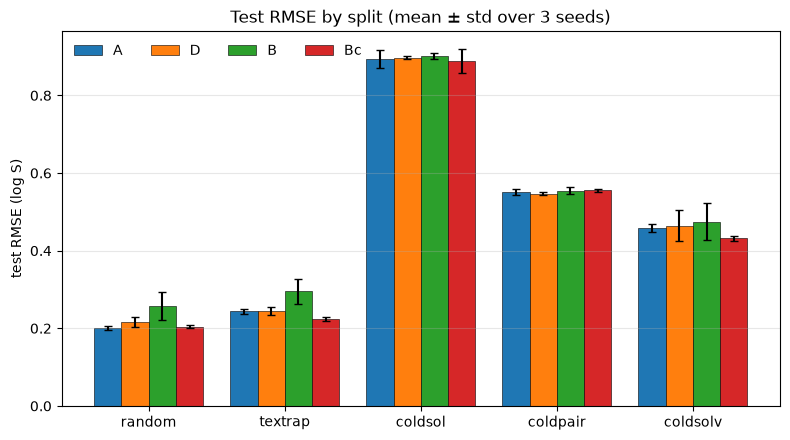

In [8]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 4.5))
x = np.arange(len(SPLITS))
width = 0.2
colors = {"A": "#1f77b4", "D": "#ff7f0e", "B": "#2ca02c", "Bc": "#d62728"}
for i, m in enumerate(MODELS):
    means = mean_by_split[m].values
    stds = std_by_split[m].values
    ax.bar(x + (i - 1.5) * width, means, width, yerr=stds, capsize=3,
           label=m, color=colors[m], edgecolor="black", linewidth=0.4)

ax.set_xticks(x)
ax.set_xticklabels(SPLITS)
ax.set_ylabel("test RMSE (log S)")
ax.set_title("Test RMSE by split (mean $\pm$ std over 3 seeds)")
ax.legend(loc="upper left", ncol=4, frameon=False)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(RES / "fig_benchmark_by_split.png", dpi=140, bbox_inches="tight")
plt.show()


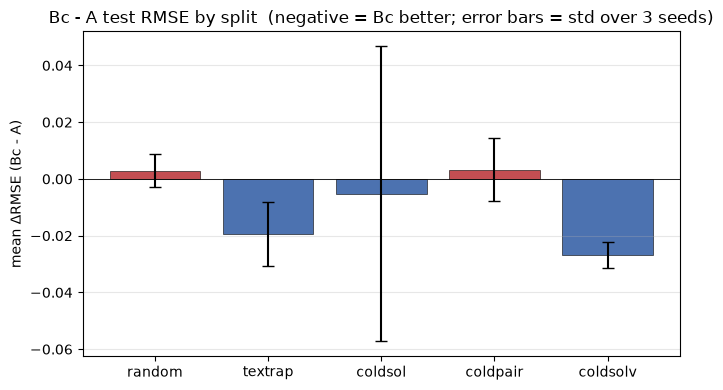

In [9]:
fig, ax = plt.subplots(figsize=(7, 4))
delta_mean = delta.groupby("split").mean().reindex(SPLITS)
delta_std = delta.groupby("split").std().reindex(SPLITS)
xpos = np.arange(len(SPLITS))
ax.bar(xpos, delta_mean.values, yerr=delta_std.values, capsize=4,
       color=["#4c72b0" if v < 0 else "#c44e52" for v in delta_mean.values],
       edgecolor="black", linewidth=0.4)
ax.axhline(0, color="k", linewidth=0.6)
ax.set_xticks(xpos)
ax.set_xticklabels(SPLITS)
ax.set_ylabel("mean $\Delta$RMSE (Bc - A)")
ax.set_title("Bc - A test RMSE by split  (negative = Bc better; error bars = std over 3 seeds)")
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(RES / "fig_delta_bc_minus_a.png", dpi=140, bbox_inches="tight")
plt.show()


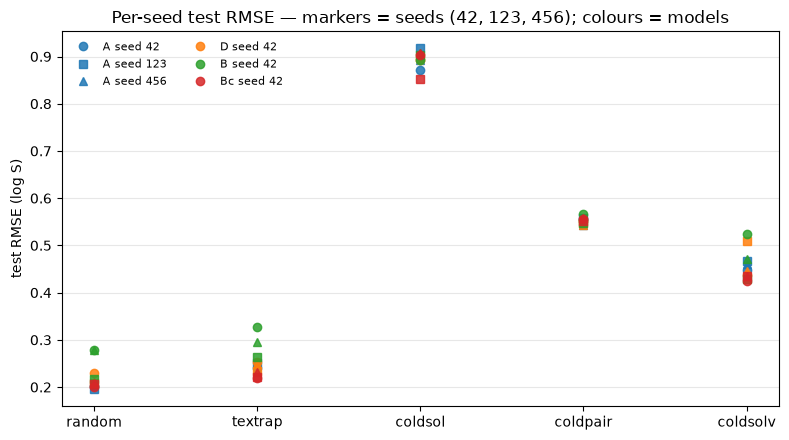

In [10]:
fig, ax = plt.subplots(figsize=(8, 4.5))
markers = {42: "o", 123: "s", 456: "^"}
for m in MODELS:
    for seed in SEEDS:
        vals = per_seed.xs(seed, level="seed")[m].reindex(SPLITS).values
        ax.plot(range(len(SPLITS)), vals, marker=markers[seed], color=colors[m],
                linestyle="", alpha=0.85,
                label=f"{m} seed {seed}" if m == MODELS[0] or seed == SEEDS[0] else None)
ax.set_xticks(range(len(SPLITS)))
ax.set_xticklabels(SPLITS)
ax.set_ylabel("test RMSE (log S)")
ax.set_title("Per-seed test RMSE — markers = seeds (42, 123, 456); colours = models")
# Deduplicated legend
handles, labels = ax.get_legend_handles_labels()
uniq = dict(zip(labels, handles))
ax.legend(uniq.values(), uniq.keys(), ncol=2, frameon=False, fontsize=8, loc="upper left")
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(RES / "fig_per_seed_scatter.png", dpi=140, bbox_inches="tight")
plt.show()


## 9. Provisional interpretation

The intent of this notebook is to establish a stable baseline; statistical
claims are deferred to the bootstrap in notebook 07. What can be read from the
tables above (without inference from three seeds alone):

- **Direction consistency across seeds.** For each split, does Bc − A have the
  same sign for all three seeds? If yes, that is a *stable trend* candidate for
  the bootstrap. If seeds disagree, it is a tie under this evidence.
- **Magnitude vs seed noise.** If the mean |Bc − A| for a split is smaller than
  the seed std within either model, no statistical claim is possible from three
  seeds regardless of sign consistency.

Explicitly not claimed here:

- Nothing is called *statistically significant*. That requires the paired
  cluster bootstrap and belongs to notebook 07.
- The old "relative degradation from random split" framing is not used, per
  the correction recorded in `results/run_log.md`. That metric mechanically
  rewarded a weak in-distribution baseline.
- Bc's absolute performance vs A on cold-solute or cold-pair is not framed as
  physics-informed generalization until the intercept-vs-slope decomposition in
  notebook 07 tests the mechanistic hypothesis.


In [11]:
# Categorical direction labels per split, computed from the actual runs.
labels = []
for s in SPLITS:
    d = delta.xs(s, level="split")  # pd.Series indexed by seed
    signs = np.sign(d.values)
    all_same_direction = bool(np.all(signs == signs[0]) and signs[0] != 0)
    dstd = float(d.std())
    dmean = float(d.mean())
    seed_noise_A = float(per_seed.xs(s, level="split")["A"].std())
    seed_noise_Bc = float(per_seed.xs(s, level="split")["Bc"].std())
    resolves = abs(dmean) > max(seed_noise_A, seed_noise_Bc)
    if all_same_direction and resolves:
        label = "stable trend"
    elif all_same_direction and not resolves:
        label = "consistent direction but within seed noise"
    else:
        label = "mixed / approximate tie"
    labels.append({
        "split": s,
        "mean(Bc-A)": round(dmean, 4),
        "std(Bc-A)": round(dstd, 4),
        "seed_std A": round(seed_noise_A, 4),
        "seed_std Bc": round(seed_noise_Bc, 4),
        "signs agree": all_same_direction,
        "label": label,
    })
pd.DataFrame(labels).set_index("split")


,mean(Bc-A),std(Bc-A),seed_std A,seed_std Bc,signs agree,label
split,,,,,,
random,0.0029,0.0059,0.0053,0.0044,False,mixed / approximate tie
textrap,-0.0194,0.0113,0.0069,0.0060,True,stable trend
coldsol,-0.0052,0.0520,0.0232,0.0308,False,mixed / approximate tie
coldpair,0.0033,0.0110,0.0079,0.0036,False,mixed / approximate tie
coldsolv,-0.0267,0.0046,0.0098,0.0067,True,stable trend


## 10. Learned slope metadata

Sanity diagnostic on the effective Van't Hoff slopes learned by B and Bc, per
split. Compare against the empirical `b_scale ≈ 1381 K` computed from
per-pair OLS on training data. Consistency with `b_scale` suggests the physics
head is at least in the right numerical regime; large deviations are worth
investigating in notebook 07's slope-recovery analysis.

Reported per (model, split), aggregated across the 3 seeds' test-set slopes:
median $b$, median $|b|$, 5th percentile, 95th percentile.


In [12]:
slope_rows = []
for kind in ("B", "Bc"):
    for split in SPLITS:
        bs = []
        for seed in SEEDS:
            fp = PREDS_DIR / f"preds_{kind}_{split}_seed{seed}.npz"
            d = np.load(fp, allow_pickle=True)
            bs.append(d["slope_b"])
        b_all = np.concatenate(bs).astype(np.float64)
        slope_rows.append({
            "model": kind,
            "split": split,
            "n": int(len(b_all)),
            "median b": round(float(np.median(b_all)), 2),
            "median |b|": round(float(np.median(np.abs(b_all))), 2),
            "p5": round(float(np.percentile(b_all, 5)), 2),
            "p95": round(float(np.percentile(b_all, 95)), 2),
            "b_scale (train pairs)": round(b_scales[split], 2) if kind == "Bc" else None,
        })
pd.DataFrame(slope_rows).set_index(["model", "split"])


n  median b  median |b|      p5      p95  \
model split                                                    
B     random    30297   1116.87     1116.87  667.71  1875.58   
      textrap   77088    965.82      965.82  530.15  1757.57   
      coldsol   31308    343.99      343.99    8.54   802.47   
      coldpair  29970   1128.04     1128.04  719.81  1857.95   
      coldsolv  35220    276.39      276.39   13.93  1503.83   
Bc    random    30297   1337.26     1337.26  812.36  2181.70   
      textrap   77088   1260.39     1260.44  781.10  2028.28   
      coldsol   31308   1194.12     1194.12  654.79  1945.19   
      coldpair  29970   1353.38     1353.38  815.84  2104.57   
      coldsolv  35220   1458.57     1458.57  900.41  2185.05   

                b_scale (train pairs)  
model split                            
B     random                      NaN  
      textrap                     NaN  
      coldsol                     NaN  
      coldpair                    NaN  
      coldsolv                    NaN  
Bc    random                  1381.78  
      textrap                 1342.21  
      coldsol                 1387.12  
      coldpair                1381.24  
      coldsolv                1386.25